In [3]:
'''

Numpy should be on version <2
This was done on apple silicon


apple silicon is fast with AI

'''

import torch

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import sys
import os

print("Done")

Done


In [2]:
import torchvision
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
import numpy
print("Done")

Done


In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device) # Apple Silicon, not Nvidia GPU

mps


In [6]:
train_set = torchvision.datasets.MNIST("./data/", train=True, download=True)
valid_set = torchvision.datasets.MNIST("./data/", train=False, download=True)

In [9]:
def numpy_check():

    print(f"Python Path: {sys.executable}")
    try:
        import numpy
        print(f"NumPy Version: {numpy.__version__}")
        print(f"NumPy Location: {os.path.dirname(numpy.__file__)}")
    except ImportError:
        print("NumPy is definitely NOT reachable by this kernel.")




In [10]:
numpy_check()


Python Path: /Users/billy/Code/Python/Lab/.venv/bin/python3.14
NumPy Version: 1.26.4
NumPy Location: /Users/billy/Code/Python/Lab/.venv/lib/python3.14/site-packages/numpy


In [29]:
x_0, y_0 = train_set[0]

In [34]:
x_0


In [35]:
y_0


5

In [37]:
type(x_0)



PIL.Image.Image

In [38]:
type(y_0)

int

In [49]:

trans = transforms.Compose([
    transforms.ToImage(),        
    transforms.ToDtype(torch.float32, scale=True), 
]) # ToTensor is deprecated


# trans = transforms.Compose([transforms.ToTensor()]) 
x_0_tensor = trans(x_0)

In [50]:
x_0_tensor.dtype

torch.float32

In [51]:
x_0_tensor.min()

tensor(0.)

In [52]:
x_0_tensor.max()

tensor(1.)

In [53]:
x_0_tensor.size()

torch.Size([1, 28, 28])

In [54]:
x_0_tensor

Image([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [55]:
x_0_tensor.device


device(type='cpu')

In [57]:
x_0_mps = x_0_tensor.to("mps") # Apple Silicon

In [59]:
x_0_mps.device

device(type='mps', index=0)

In [60]:
x_0_tensor.to(device).device

device(type='mps', index=0)

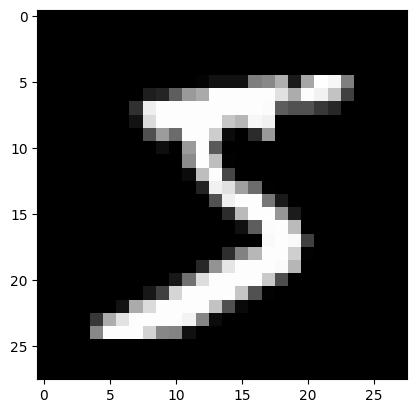

In [62]:
image = F.to_pil_image(x_0_tensor)
plt.imshow(image, cmap='gray')

In [ ]:
## Data Training

In [67]:
trans = transforms.Compose([transforms.ToTensor()])
train_set.transform = trans
valid_set.transform = trans
print("Executed!")

Executed!


In [70]:
batch_size = 32

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
print("Executed")

Executed


In [80]:

test_matrix = torch.tensor(
    [[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9]]
)
test_matrix

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [72]:
nn.Flatten()(test_matrix)

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [73]:
batch_test_matrix = test_matrix[None, :]
batch_test_matrix

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]])

In [74]:
nn.Flatten()(batch_test_matrix)

tensor([[1, 2, 3, 4, 5, 6, 7, 8, 9]])

In [75]:
nn.Flatten()(test_matrix[:, None])

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [83]:
input_size = 1 * 28 * 28
n_classes = 10
layers = [
    nn.Flatten(),
    nn.Linear(input_size, 512),  # Input
    nn.ReLU(),  # Activation for input
    nn.Linear(512, 512),  # Hidden
    nn.ReLU(),  # Activation for hidden
    nn.Linear(512, n_classes)  # Output
]
layers

[Flatten(start_dim=1, end_dim=-1),
 Linear(in_features=784, out_features=512, bias=True),
 ReLU(),
 Linear(in_features=512, out_features=512, bias=True),
 ReLU(),
 Linear(in_features=512, out_features=10, bias=True)]

In [104]:

model = nn.Sequential(*layers)
model.to(device)
next(model.parameters()).device


model = torch.compile(model)


loss_function = nn.CrossEntropyLoss()

optimizer = Adam(model.parameters())


print("Executed")

Executed


In [107]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [117]:
def train():
    train_N = len(train_loader.dataset)
    
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [116]:
def validate():
    valid_N = len(valid_loader.dataset)
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [118]:
epochs = 5

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()
print("Executed")

Epoch: 0
Train - Loss: 371.7253 Accuracy: 0.9407
Valid - Loss: 33.7102 Accuracy: 0.9665
Epoch: 1
Train - Loss: 158.2179 Accuracy: 0.9748
Valid - Loss: 39.4164 Accuracy: 0.9602
Epoch: 2
Train - Loss: 110.5742 Accuracy: 0.9816
Valid - Loss: 26.7128 Accuracy: 0.9743
Epoch: 3
Train - Loss: 84.2683 Accuracy: 0.9856
Valid - Loss: 26.6100 Accuracy: 0.9762
Epoch: 4
Train - Loss: 67.5209 Accuracy: 0.9885
Valid - Loss: 22.0193 Accuracy: 0.9802


In [121]:
prediction = model(x_0_mps)
prediction
prediction.argmax(dim=1, keepdim=True)
y_0

5

In [122]:
# Shutdown

import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}